# Word Embedding Comparison on QUAERO

This notebook compares different word embedding strategies trained on the QUAERO French corpora. The objective is to study how the **training corpus**, **embedding architecture**, and **number of training epochs** affect the learned representations before using them in a downstream Named Entity Recognition (NER) task.

| Setting | Description |
|---|---|
| Corpora | `QUAERO_FrenchMed` and `QUAERO_FrenchPress` |
| Approaches | Word2Vec CBOW, Word2Vec Skip-gram, and FastText CBOW |
| Epochs | 5 to 100, evaluated every 5 epochs |
| Embedding dimension | 100 |
| Minimum word count | 1 |
| Total configurations | 2 corpora × 3 approaches × 20 epoch values = **120** |

The embeddings are evaluated intrinsically through nearest-neighbour inspection and three complementary geometric measures: **anisotropy, contrast, and separation**. These results are then used to select candidate embeddings for the downstream NER experiment.

## 1. Requirements



In [1]:
# %pip install gensim numpy pandas matplotlib scipy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import FastText, KeyedVectors, Word2Vec
from gensim.models.callbacks import CallbackAny2Vec


In [2]:
TP = Path("TP_ISD2020")
CORPORA = {
    "med": TP / "QUAERO_FrenchMed" / "QUAERO_FrenchMed_traindev.ospl",
    "press": TP / "QUAERO_FrenchPress" / "QUAERO_FrenchPress_traindev.ospl"
}

APPROACHES = ["cbow", "skipgram", "fasttext"]
EPOCHS = list(range(5, 101, 5))

DIM = 100
MIN_COUNT = 1
NEGATIVE = 5
WINDOW = 5
SAMPLE = 1e-3
WORKERS = 1
SEED = 42

TOPN = 10
N_RANDOM_PAIRS = 2000

MODEL_ROOT = Path("models")
MODELS = MODEL_ROOT / "context_preserved"
MODELS.mkdir(parents=True, exist_ok=True)


## 2. Corpora and preprocessing

The embeddings are trained on two QUAERO corpora: **FrenchMed**, which contains biomedical text, and **FrenchPress**, which contains general-domain press text.

Each line corresponds to a tokenized sentence. All tokens are converted to lowercase to keep the preprocessing consistent with the embedding lookup used later in the NER model.

Stopwords and punctuation are preserved because they contribute to the local context from which Word2Vec and FastText learn their representations. Removing them would modify the original co-occurrence structure of the corpus.



In [3]:
def read_sentences(path):
    """Read tokenized sentences and convert all tokens to lowercase."""
    lines = path.read_text(encoding="utf-8").splitlines()
    return [line.lower().split() for line in lines if line.strip()]


sentences = {
    name: read_sentences(path)
    for name, path in CORPORA.items()
}

vocabularies = {
    name: {word for sentence in corpus for word in sentence}
    for name, corpus in sentences.items()
}


In [4]:
stats = pd.DataFrame({
    name: [
        len(corpus),
        sum(len(sentence) for sentence in corpus),
        len(vocabularies[name])
    ]
    for name, corpus in sentences.items()
}, index=["sentences", "tokens", "word types"])

display(stats)
print("med   :", " ".join(sentences["med"][12]))
print("press :", " ".join(sentences["press"][0]))


,med,press
sentences,3021,38548
tokens,51896,1251561
word types,8088,38279


med   : la plupart des patients nécessitent des doses inférieures à 9 , 6 microgrammes par jour .
press : patricia martin , que voici , que voilà ! oh , bonjour nicolas stoufflet .


### Insights

> The two corpora differ substantially in both size and domain. The PRESS corpus contains approximately **1.25 million tokens**, compared with around **52 thousand tokens** in MED, making it roughly **24 times larger**. It also contains considerably more unique word types.
>
> This difference is important when interpreting the results. PRESS provides much more training data and greater lexical diversity, whereas MED is considerably smaller but more closely aligned with the biomedical domain of the downstream NER task. Therefore, differences between the resulting embeddings may reflect both **corpus size** and **domain specificity**.

## 3. Embedding training

For each corpus, CBOW, Skip-gram, and FastText models are trained independently for every epoch value between 5 and 100. All configurations use the same embedding dimension, context window, subsampling, and random seed.

The implementation uses `WORKERS=8`. Although a fixed random seed is used, multi-threaded Gensim training is not guaranteed to be exactly deterministic across runs. The seed therefore improves reproducibility without ensuring identical results at the numerical level.

Previously trained models are loaded when available unless `RETRAIN_MODELS=True`. The corpus hash and training configuration are stored with each model to ensure that saved models correspond to the current experimental setting.

FastText is trained using the CBOW objective together with character-level subword information. Its training loss is not included in the following loss-curve analysis because the callback used here does not provide an equivalent informative curve.


In [5]:
class LossLogger(CallbackAny2Vec):
    def __init__(self):
        self.losses = []
        self.previous_loss = 0.0

    def on_epoch_end(self, model):
        cumulative_loss = model.get_latest_training_loss()
        self.losses.append(cumulative_loss - self.previous_loss)
        self.previous_loss = cumulative_loss


def model_path(corpus, approach, epoch):
    kind = "ft_cbow" if approach == "fasttext" else f"w2v_{approach}"
    return MODELS / f"{corpus}_{kind}_e{epoch}.model"


def train_or_load(corpus, approach, epoch):
    path = model_path(corpus, approach, epoch)
    model_class = FastText if approach == "fasttext" else Word2Vec

    if path.exists():
        model = model_class.load(str(path))
    else:
        options = {
            "sentences": sentences[corpus],
            "vector_size": DIM,
            "min_count": MIN_COUNT,
            "window": WINDOW,
            "negative": NEGATIVE,
            "sample": SAMPLE,
            "workers": WORKERS,
            "seed": SEED,
            "epochs": epoch,
            "sg": int(approach == "skipgram")
        }

        if approach == "fasttext":
            model = FastText(bucket=200_000, **options)
            model.epoch_losses = []
        else:
            logger = LossLogger()
            model = Word2Vec(
                compute_loss=True,
                callbacks=[logger],
                **options
            )
            model.epoch_losses = logger.losses

        model.save(str(path))

    vectors = model.wv

    if approach == "fasttext":
        vectors = KeyedVectors(vector_size=model.wv.vector_size)
        vectors.add_vectors(model.wv.index_to_key, model.wv.vectors)

    return vectors, model.epoch_losses


### 3.2 Train and save all configurations

Both dictionaries use `(approach, corpus, epoch)` keys.


In [6]:
models, losses = {}, {}
for approach in APPROACHES:
    for corpus in CORPORA:
        for epoch in EPOCHS:
            key = (approach, corpus, epoch)
            models[key], losses[key] = train_or_load(corpus, approach, epoch)
            print(f"{approach} | {corpus} | {epoch} epochs ready")


cbow | med | 5 epochs ready
cbow | med | 10 epochs ready
cbow | med | 15 epochs ready
cbow | med | 20 epochs ready
cbow | med | 25 epochs ready
cbow | med | 30 epochs ready
cbow | med | 35 epochs ready
cbow | med | 40 epochs ready
cbow | med | 45 epochs ready
cbow | med | 50 epochs ready
cbow | med | 55 epochs ready
cbow | med | 60 epochs ready
cbow | med | 65 epochs ready
cbow | med | 70 epochs ready
cbow | med | 75 epochs ready
cbow | med | 80 epochs ready
cbow | med | 85 epochs ready
cbow | med | 90 epochs ready
cbow | med | 95 epochs ready
cbow | med | 100 epochs ready
cbow | press | 5 epochs ready
cbow | press | 10 epochs ready
cbow | press | 15 epochs ready
cbow | press | 20 epochs ready
cbow | press | 25 epochs ready
cbow | press | 30 epochs ready
cbow | press | 35 epochs ready
cbow | press | 40 epochs ready
cbow | press | 45 epochs ready
cbow | press | 50 epochs ready
cbow | press | 55 epochs ready
cbow | press | 60 epochs ready
cbow | press | 65 epochs ready
cbow | press | 70 

### 3.3 Word2Vec loss curves

Each point is the increase in Gensim's cumulative loss during one epoch.
Use it as a training diagnostic within a run. Different epoch configurations
have different learning-rate schedules, and absolute losses are not comparable
across corpus sizes or architectures. A lower loss does not establish better
semantic or NER performance. Very long runs can also lose numerical precision
in the cumulative loss, so a flat curve does not prove convergence.


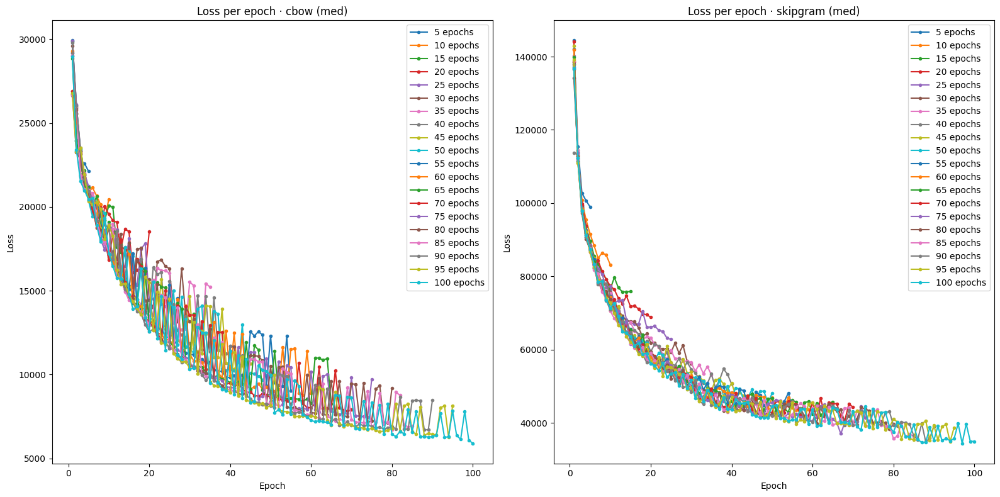

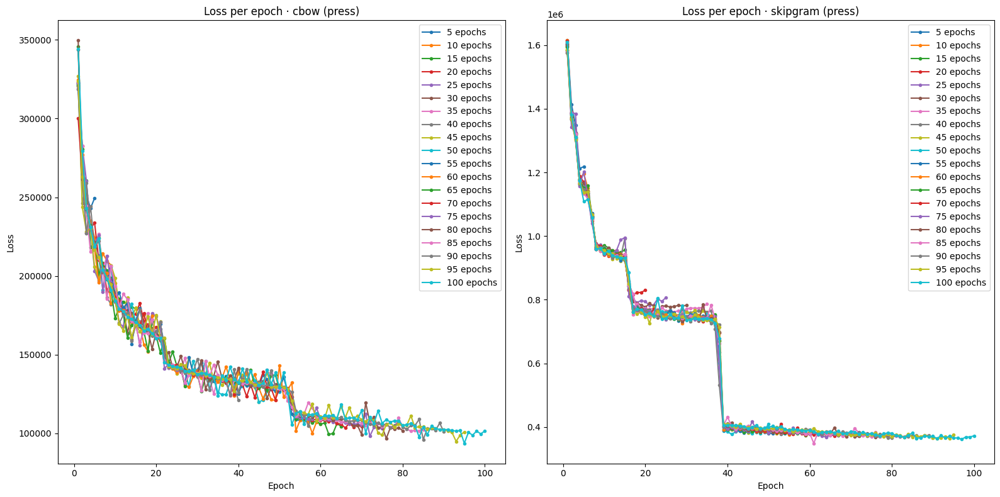

In [7]:
def plot_losses(corpus_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, approach in zip(axes, ["cbow", "skipgram"]):
        for epoch in EPOCHS:
            ax.plot(range(1, epoch + 1), losses[approach, corpus_name, epoch],
                    marker=".", label=f"{epoch} epochs")
        ax.set(title=f"Loss per epoch · {approach} ({corpus_name})",
               xlabel="Epoch", ylabel="Loss")
        ax.legend()
    plt.tight_layout()
    plt.show()


for corpus_name in CORPORA:
    plot_losses(corpus_name)


## 4. Intrinsic evaluation

The embeddings are evaluated using both qualitative and quantitative criteria.

Five French probe words are used to inspect their nearest neighbours across the different models and training durations. In addition, a small set of manually defined related and unrelated word pairs is used to characterize the geometry of the embedding space.

The same probe words and word pairs are used across corpora and embedding approaches to make the comparison consistent. FastText-generated out-of-vocabulary vectors are excluded from this intrinsic comparison so that all models are evaluated on explicitly observed vocabulary items.

These examples provide a useful diagnostic of embedding behaviour, but they should not be interpreted as a general semantic benchmark. The evaluation set is deliberately small, and the resulting scores may therefore be sensitive to the selected words and pairs.

In [8]:
PROBE = ["patient", "maladie", "solution", "traitement", "jaune"]

RELATED = [
    ("patient", "patients"),
    ("maladie", "pathologie"),
    ("solution", "préparation"),
    ("traitement", "thérapie")
]

UNRELATED = [
    ("patient", "jaune"),
    ("maladie", "jaune"),
    ("solution", "patients"),
    ("traitement", "jaune")
]

COMMON_WORDS = set.intersection(*vocabularies.values())

EVAL_PROBES = [word for word in PROBE if word in COMMON_WORDS]
EVAL_RELATED = [
    pair for pair in RELATED
    if all(word in COMMON_WORDS for word in pair)
]
EVAL_UNRELATED = [
    pair for pair in UNRELATED
    if all(word in COMMON_WORDS for word in pair)
]

print(
    f"Shared probes: {len(EVAL_PROBES)} | "
    f"Related pairs: {len(EVAL_RELATED)} | "
    f"Comparison pairs: {len(EVAL_UNRELATED)}"
)


Shared probes: 5 | Related pairs: 4 | Comparison pairs: 4


### 4.1 Nearest neighbours across training epochs

The following heatmaps show the nearest neighbours of each probe word at different stages of training. Each cell contains a retrieved word together with its cosine similarity to the corresponding probe.

This provides a qualitative view of how the local structure of the embedding space evolves as training progresses. Both the magnitude of the cosine similarities and the semantic relevance of the retrieved neighbours can be inspected.

Nearest-neighbour analysis alone, however, is not sufficient to select the best embedding. High cosine similarities may arise even when the global geometry of the embedding space is poorly structured, and in FastText they may also reflect morphological or orthographic similarity.

For this reason, the qualitative analysis is complemented with three quantitative measures: **anisotropy, contrast, and separation**.

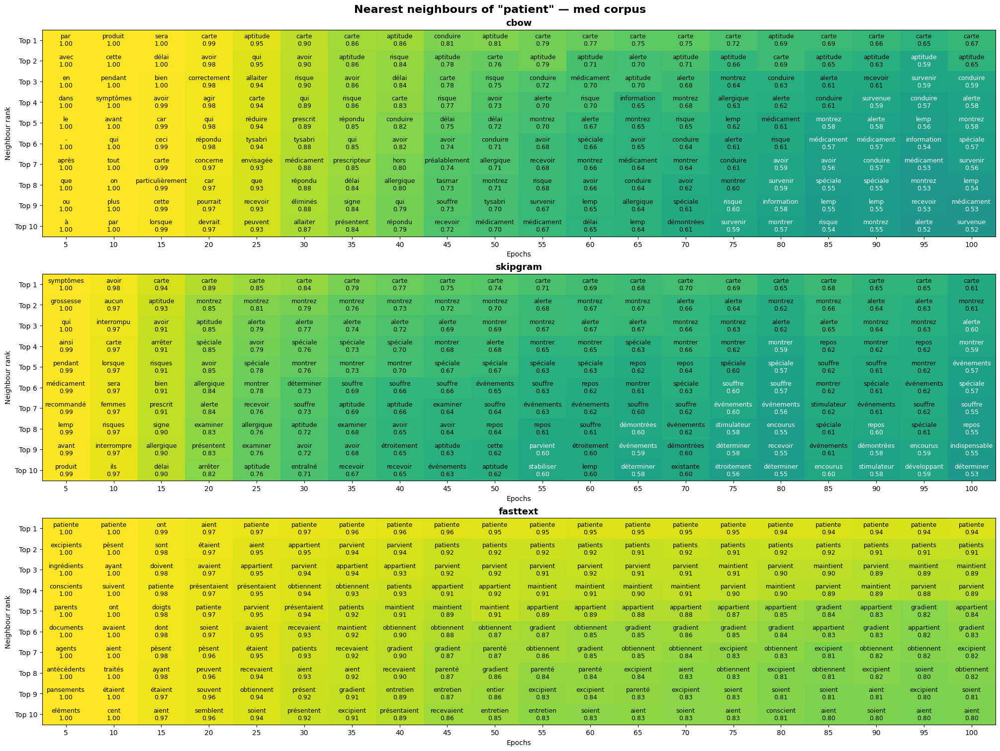

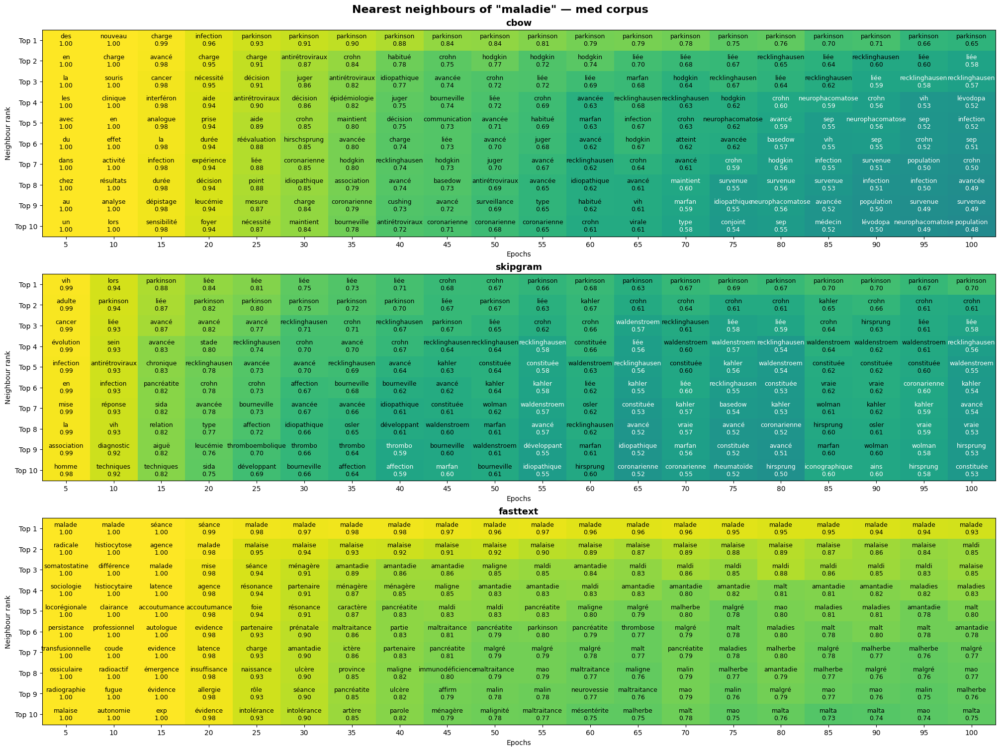

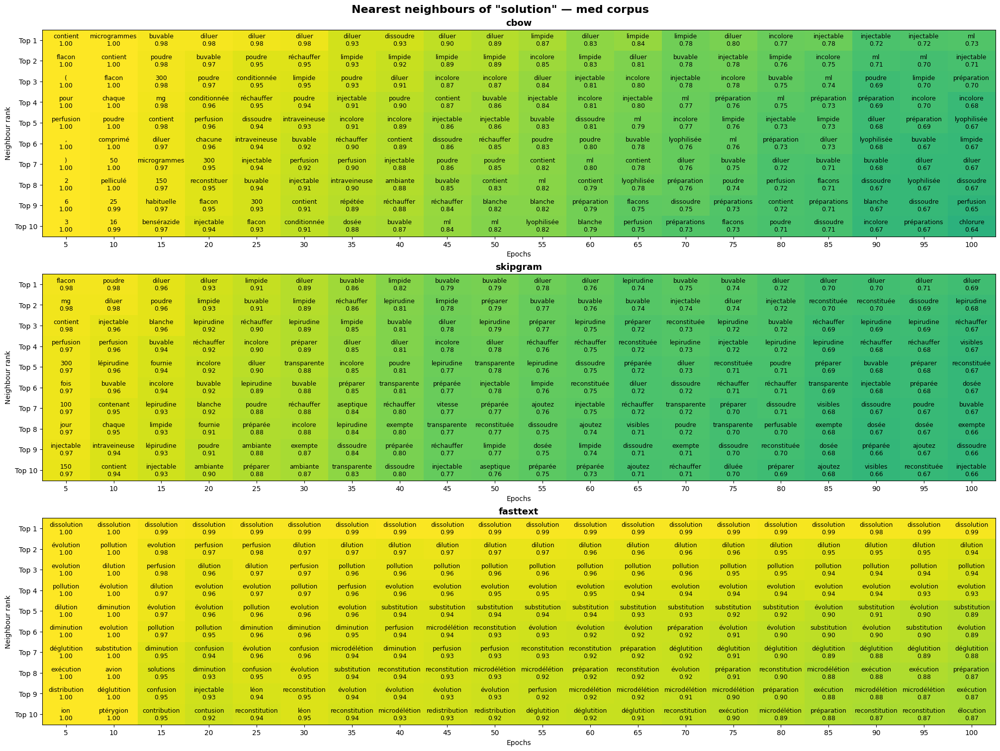

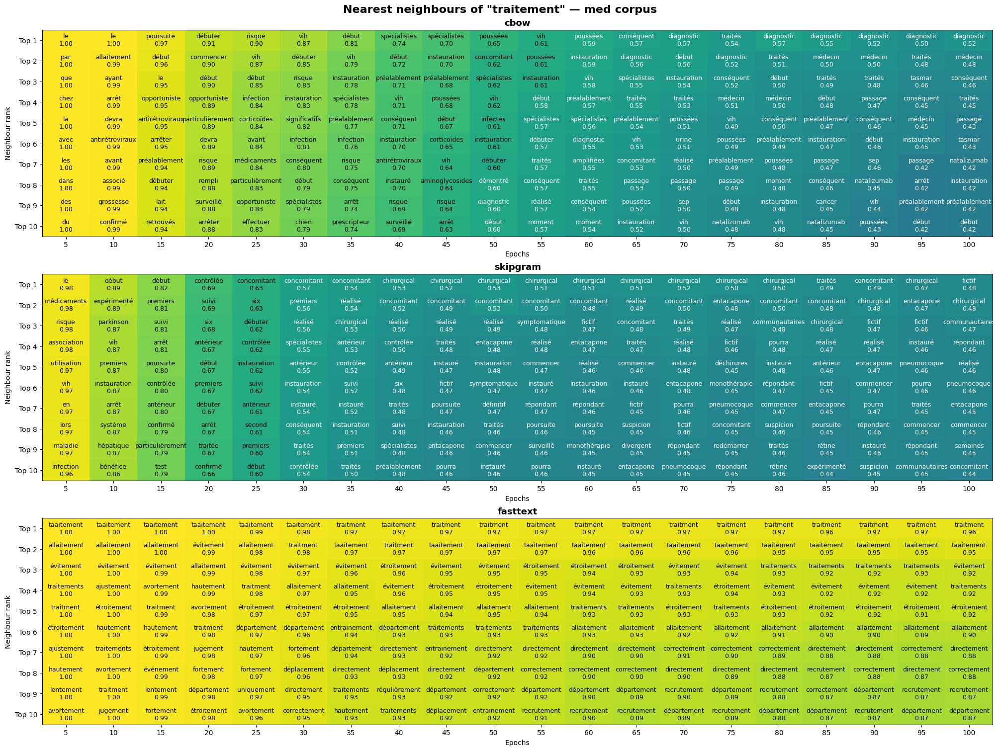

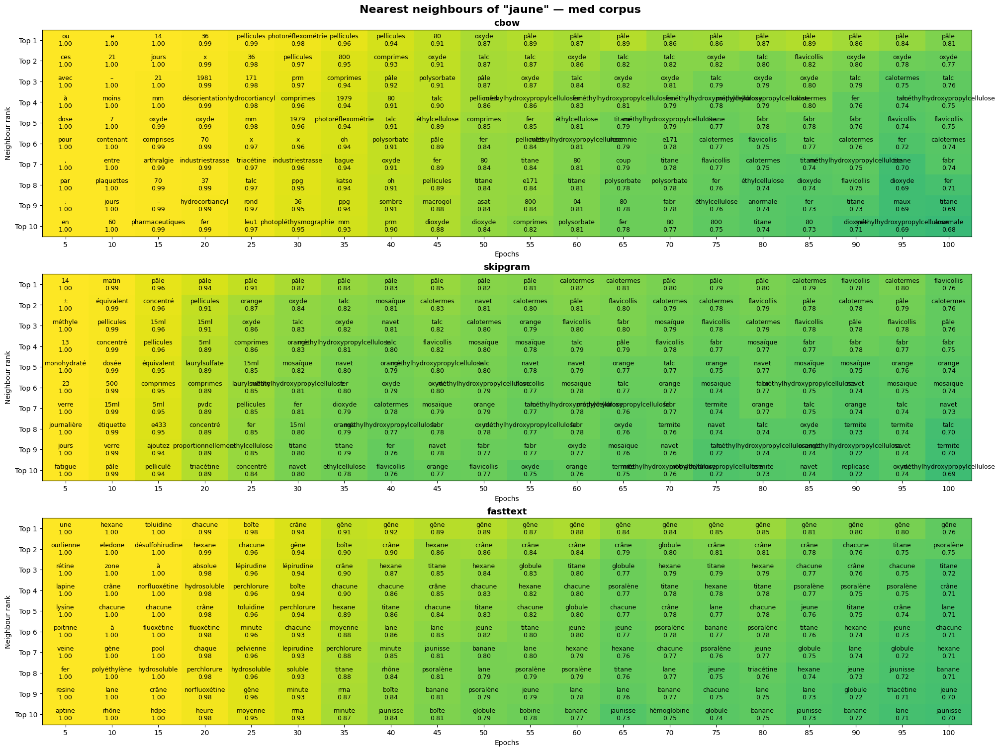

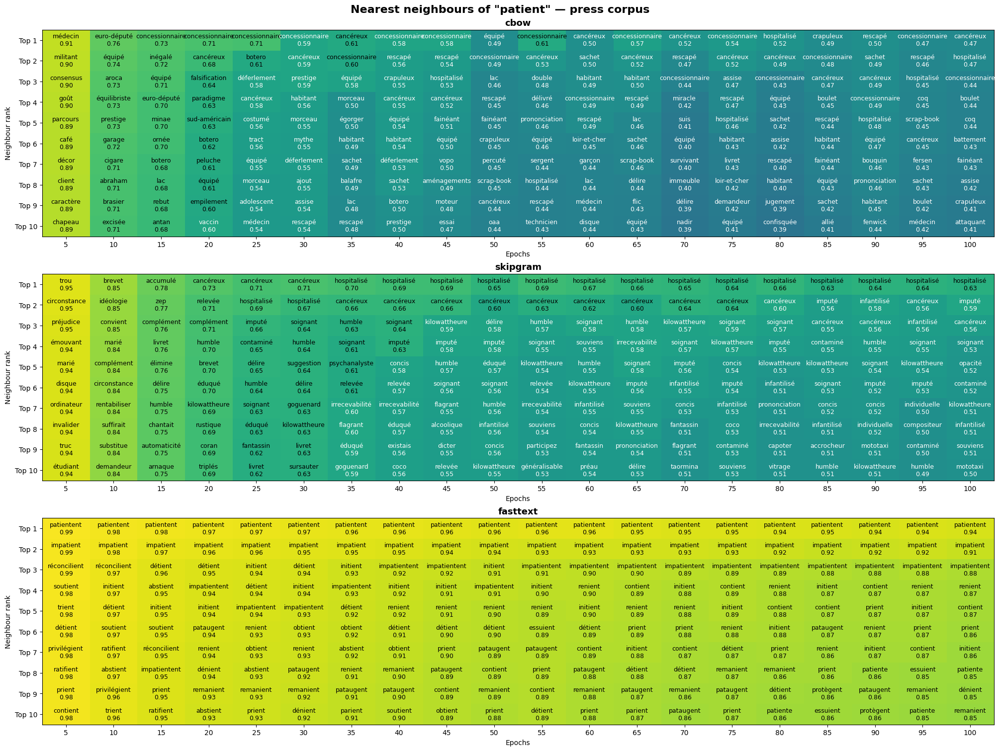

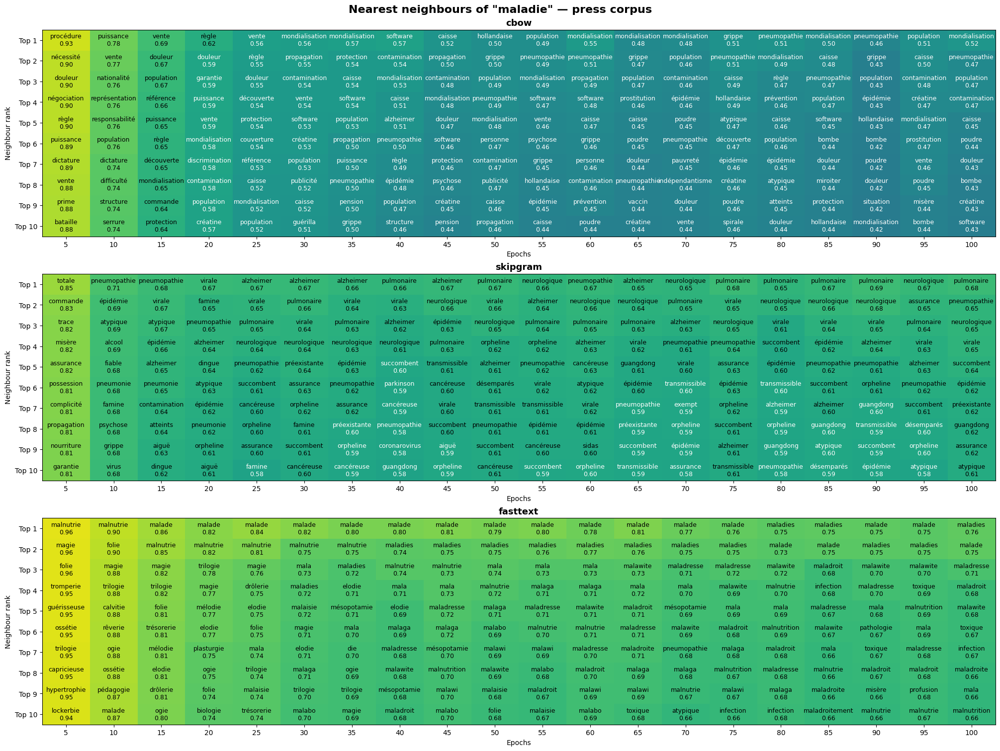

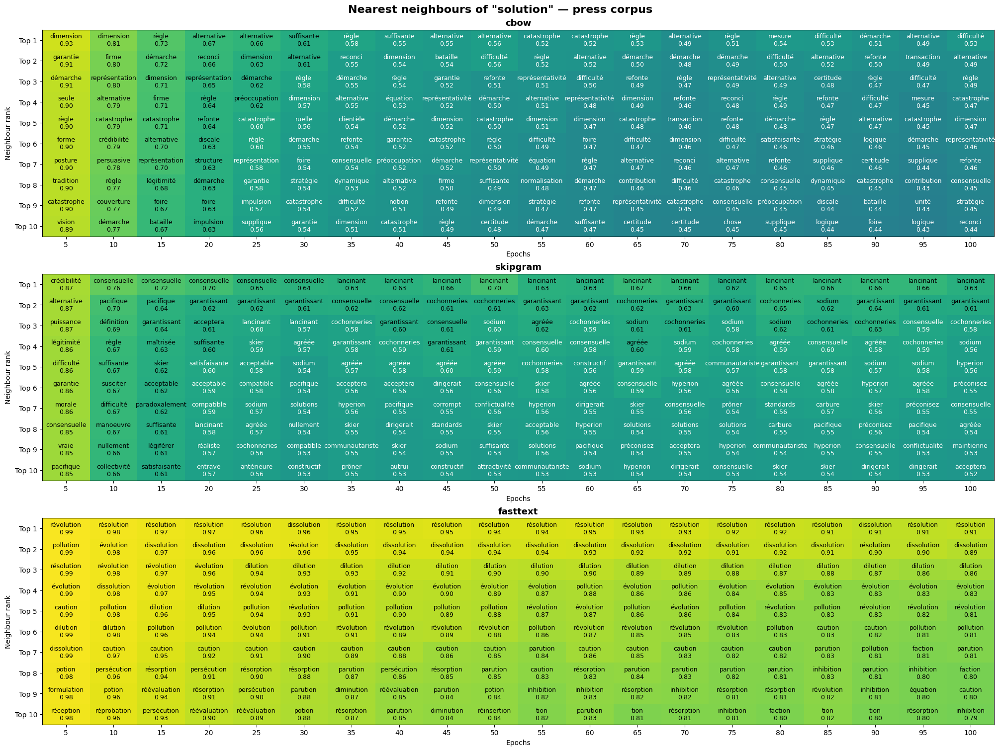

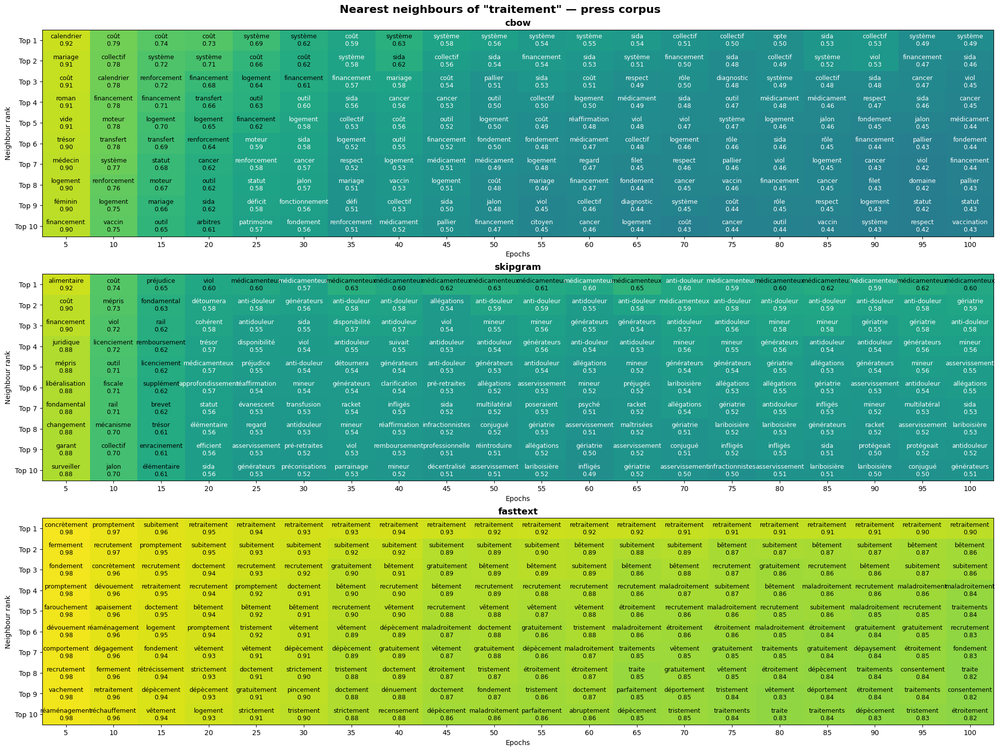

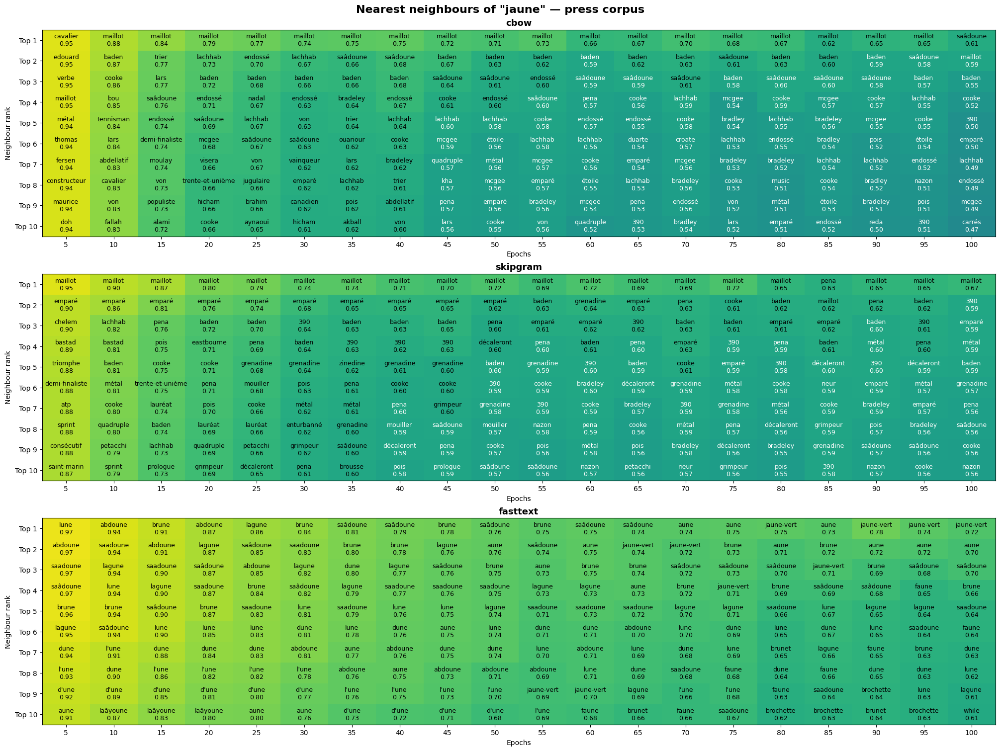

In [9]:
def heatmap_epochs(word, corpus_name, topn=TOPN):
    fig, axes = plt.subplots(len(APPROACHES), 1, figsize=(max(16, len(EPOCHS)), 5 * len(APPROACHES)),
                             constrained_layout=True)
    for ax, approach in zip(axes, APPROACHES):
        if word not in vocabularies[corpus_name]:
            ax.set_title(f"{approach}: {word} is not in the trained vocabulary")
            ax.axis("off")
            continue
        neighbours_per_epoch = [
            models[approach, corpus_name, epoch].most_similar(word, topn=topn)
            for epoch in EPOCHS
        ]
        similarities = np.array([
            [score for _, score in neighbours] for neighbours in neighbours_per_epoch
        ]).T
        image = ax.imshow(similarities, vmin=0, vmax=1, cmap="viridis", aspect="auto")

        for column, neighbours in enumerate(neighbours_per_epoch):
            for row, (neighbour, score) in enumerate(neighbours):
                color = "white" if score < 0.6 else "black"
                ax.text(column, row, f"{neighbour}\n{score:.2f}", ha="center",
                        va="center", fontsize=9, color=color)

        ax.set_title(approach, fontsize=13, fontweight="bold")
        ax.set_xticks(range(len(EPOCHS)), labels=EPOCHS)
        ax.set_yticks(range(topn), labels=[f"Top {rank}" for rank in range(1, topn + 1)])
        ax.set(xlabel="Epochs", ylabel="Neighbour rank")

    fig.suptitle(f'Nearest neighbours of "{word}" — {corpus_name} corpus',
                 fontsize=16, fontweight="bold")
    plt.show()


for word in PROBE:
    heatmap_epochs(word, "med")

for word in PROBE:
    heatmap_epochs(word, "press")  


### 4.2 Anisotropy

Anisotropy measures how similarly the word vectors are oriented in the embedding space. We estimate it as the mean cosine similarity between $N$ randomly sampled pairs of normalized word vectors:

$$
A = \frac{1}{N}\sum_{i=1}^{N}
\cos(\mathbf{v}_i,\mathbf{v}'_i)
$$

where

$$
\cos(\mathbf{v}_i,\mathbf{v}'_i)
=
\frac{\mathbf{v}_i^\top \mathbf{v}'_i}
{\|\mathbf{v}_i\|\,\|\mathbf{v}'_i\|}
$$

A higher $A$ indicates that the vectors tend to point in similar directions, suggesting a more anisotropic embedding space. In contrast, a lower value indicates that the vectors are more evenly distributed across the space.


In [10]:
def calculate_anisotropy(vectors, n_pairs=N_RANDOM_PAIRS, seed=SEED):
    normalized_vectors = vectors.get_normed_vectors()
    rng = np.random.default_rng(seed)

    first_indices = rng.integers(0, len(normalized_vectors), size=n_pairs)
    second_indices = rng.integers(0, len(normalized_vectors), size=n_pairs)

    similarities = (
        normalized_vectors[first_indices] * normalized_vectors[second_indices]
    ).sum(axis=1)

    return similarities.mean()

### 4.3 Contrast

Contrast measures how much the local neighbourhood structure differs from the global similarity level of the embedding space. It is computed as the difference between the mean nearest-neighbour similarity and the anisotropy baseline:

$$
C = \frac{1}{M}\sum_{i=1}^{M} s_i - A
$$

where $s_i$ is the cosine similarity between a probe word and one of its nearest neighbours, $M$ is the total number of neighbour similarities considered, and $A$ is the anisotropy score.

A higher $C$ indicates that local semantic neighbourhoods are more clearly separated from the global background similarity of the embedding space.

In [11]:
def calculate_contrast(vectors, probe_words, anisotropy, topn=TOPN):
    similarities = [
        score
        for word in probe_words
        for _, score in vectors.most_similar(word, topn=topn)
    ]
    return float(np.mean(similarities) - anisotropy)


### 4.4 Separation

Separation measures how well the embedding space distinguishes related word pairs from unrelated ones. It is computed as the difference between their mean cosine similarities:

$$
S = \frac{1}{R}\sum_{i=1}^{R} s_i^{\text{related}}
-
\frac{1}{U}\sum_{j=1}^{U} s_j^{\text{unrelated}}
$$

where $R$ and $U$ are the numbers of related and unrelated pairs, respectively, and $s$ represents the cosine similarity of each pair.

A larger positive $S$ indicates that related words are, on average, more similar than unrelated words, meaning the model separates the two groups more clearly.

In [12]:
def calculate_separation(vectors, related_pairs, unrelated_pairs):
    related_mean = np.mean([
        vectors.similarity(*pair)
        for pair in related_pairs
    ])

    unrelated_mean = np.mean([
        vectors.similarity(*pair)
        for pair in unrelated_pairs
    ])

    return float(related_mean - unrelated_mean)


### 4.5 Combined results

The three intrinsic metrics capture complementary properties of the embedding space:

- **Anisotropy** describes the global tendency of vectors to point in similar directions.
- **Contrast** measures how strongly local nearest-neighbour similarities stand out from this global similarity baseline.
- **Separation** measures whether the selected related word pairs are more similar than the unrelated pairs.

To summarize the local discriminative structure of each embedding, we define:

$$
\text{Weighted Separation} = \text{Contrast} \times \text{Separation}
$$

A high value therefore requires both clearly defined local neighbourhoods and a meaningful distinction between related and unrelated word pairs.

This score is used as an **intrinsic selection criterion**, rather than as a direct measure of downstream NER performance.

In [13]:
rows = []
for corpus in CORPORA:
    for approach in APPROACHES:
        for epoch in EPOCHS:
            vectors = models[approach, corpus, epoch]
            anisotropy = calculate_anisotropy(vectors)
            rows.append({
                "approach": approach, "corpus": corpus, "epoch": epoch,
                "anisotropy": anisotropy,
                "contrast": calculate_contrast(vectors, EVAL_PROBES, anisotropy),
                "separation": calculate_separation(vectors, EVAL_RELATED, EVAL_UNRELATED)
            })

results = pd.DataFrame(rows).sort_values(["corpus", "approach", "epoch"])
results["weighted_separation"] = results["separation"] * results["contrast"]
results = results.reset_index(drop=True)
display(results)


,approach,corpus,epoch,anisotropy,contrast,separation,weighted_separation
0,cbow,med,5,0.606043,0.393191,-0.000025,-0.000010
1,cbow,med,10,0.807477,0.189419,0.033485,0.006343
2,cbow,med,15,0.822510,0.157245,0.170377,0.026791
3,cbow,med,20,0.776590,0.175406,0.230447,0.040422
4,cbow,med,25,0.721960,0.198481,0.312270,0.061980
...,...,...,...,...,...,...,...
115,skipgram,press,80,0.258077,0.317140,0.118554,0.037598
116,skipgram,press,85,0.255005,0.323844,0.204574,0.066250
117,skipgram,press,90,0.252449,0.325334,0.105887,0.034449
118,skipgram,press,95,0.250865,0.324577,0.081054,0.026308


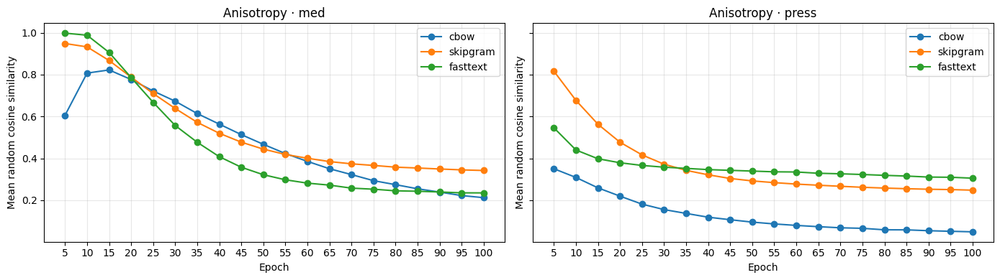

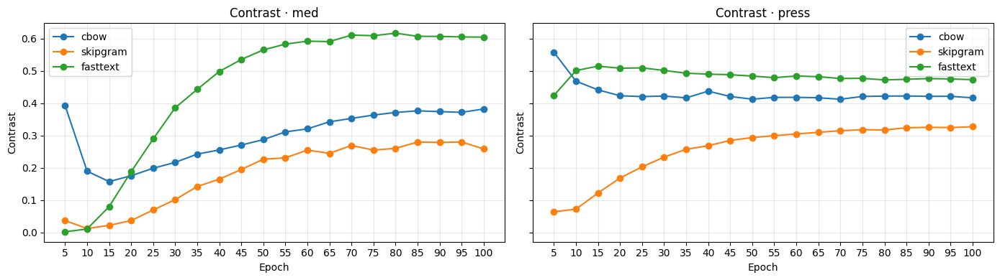

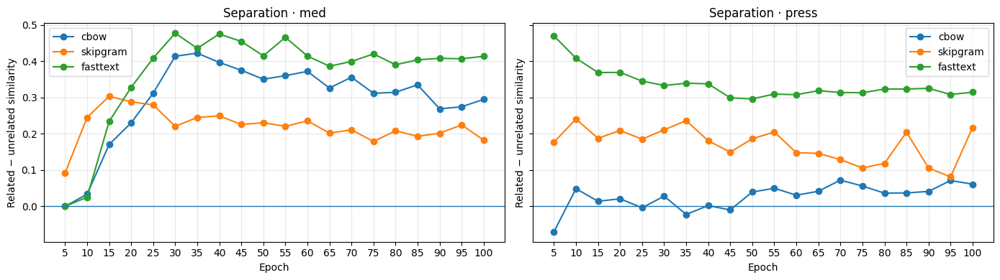

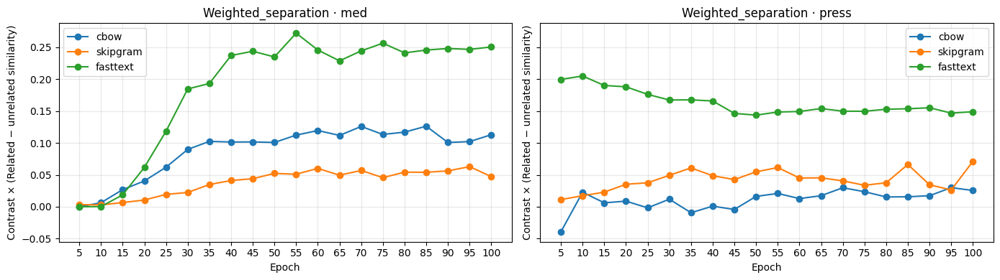

In [14]:
def plot_metric(metric, ylabel):
    fig, axes = plt.subplots(1, len(CORPORA), figsize=(14, 4), sharey=True)
    for ax, corpus_name in zip(axes, CORPORA):
        for approach in APPROACHES:
            data = results[(results["corpus"] == corpus_name)
                           & (results["approach"] == approach)]
            ax.plot(data["epoch"], data[metric], marker="o", label=approach)
        ax.set(title=f"{metric.capitalize()} · {corpus_name}", xlabel="Epoch", ylabel=ylabel)
        ax.set_xticks(EPOCHS)
        if metric == "separation":
            ax.axhline(0, linewidth=1)
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()


for metric, ylabel in {
    "anisotropy": "Mean random cosine similarity",
    "contrast": "Contrast",
    "separation": "Related − unrelated similarity",
    "weighted_separation": "Contrast × (Related − unrelated similarity)"
}.items():
    plot_metric(metric, ylabel)


#### Interpretation of the combined results

The intrinsic evaluation shows a clear advantage for **FastText** under the proposed selection criterion.

For the MED corpus, FastText reaches its highest weighted separation at **55 epochs (0.2719)**, compared with **0.1262** for CBOW at 85 epochs and **0.0628** for Skip-gram at 95 epochs. FastText also achieves the highest individual contrast and separation values within this corpus.

A similar pattern appears for PRESS. FastText obtains the highest weighted separation at **10 epochs (0.2049)**, while Skip-gram reaches **0.0712** at 100 epochs and CBOW reaches **0.0300** at 95 epochs.

These results suggest that FastText produces particularly well-defined local neighbourhoods according to the intrinsic criteria used here. However, the selected epoch should not be interpreted as a general convergence point. One PRESS epoch contains substantially more training tokens than one MED epoch, so epoch counts are not directly comparable between corpora.

In addition, weighted separation remains an exploratory metric based on a small manually defined set of words and pairs. A higher score does not necessarily imply better downstream NER performance.



## 5. Candidate selection and semantic comparison

One candidate is selected for each corpus–approach combination.

Only configurations with positive contrast and positive separation are considered. Within each group, models are ranked by weighted separation, with fewer training epochs used as a tie-breaker.

This produces an intrinsic shortlist of six embeddings rather than a final ranking of NER models. The selected configurations are:

| Corpus | Approach | Selected epoch | Weighted separation |
|---|---|---:|---:|
| MED | CBOW | 85 | 0.1262 |
| MED | FastText | 55 | **0.2719** |
| MED | Skip-gram | 95 | 0.0628 |
| PRESS | CBOW | 95 | 0.0300 |
| PRESS | FastText | 10 | **0.2049** |
| PRESS | Skip-gram | 100 | 0.0712 |

The six candidates are retained for downstream comparison because intrinsic embedding quality does not necessarily translate directly into better NER performance.

The selected configurations are exported to JSON so that the downstream experiment uses the exact models identified here without manually copying the selected epochs.


In [15]:
def select_candidates(scores):
    eligible = scores[
        (scores["separation"] > 0) &
        (scores["contrast"] > 0)
    ]

    return (
        eligible
        .sort_values(["weighted_separation", "epoch"], ascending=[False, True])
        .groupby(["corpus", "approach"], sort=False)
        .head(1)
        .sort_values(["corpus", "approach"])
        .reset_index(drop=True)
    )


candidates = select_candidates(results)
display(candidates.round(4))

selected_epochs = {
    (row.corpus, row.approach): row.epoch
    for row in candidates.itertuples()
}

selected_models = {
    (corpus, approach): models[approach, corpus, epoch]
    for (corpus, approach), epoch in selected_epochs.items()
}

embedding_files = {
    corpus.upper(): {
        approach: str(
            model_path(corpus, approach, selected_epochs[corpus, approach])
            .relative_to(MODEL_ROOT)
        )
        for approach in APPROACHES
    }
    for corpus in CORPORA
}

selection = {
    "embedding_dim": DIM,
    "selection_metric": "weighted_separation",
    "embeddings": embedding_files
}

selection_path = MODEL_ROOT / "embedding_selection.json"
selection_path.write_text(
    json.dumps(selection, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

results.to_csv(MODELS / "intrinsic_results.csv", index=False)
print(f"NER shortlist saved to {selection_path}")


,approach,corpus,epoch,anisotropy,contrast,separation,weighted_separation
0,cbow,med,85,0.2547,0.3764,0.3352,0.1262
1,fasttext,med,55,0.2976,0.5831,0.4664,0.2719
2,skipgram,med,95,0.3450,0.2798,0.2246,0.0628
3,cbow,press,95,0.0516,0.4214,0.0711,0.0300
4,fasttext,press,10,0.4400,0.5012,0.4087,0.2049
5,skipgram,press,100,0.2480,0.3272,0.2175,0.0712


NER shortlist saved to models/embedding_selection.json


### 5.1 Nearest neighbours of the selected candidates

The following tables compare the nearest neighbours produced by the six selected embedding configurations.

This provides a qualitative complement to the intrinsic scores. In particular, it allows us to examine whether high cosine similarities correspond to meaningful contextual relationships or primarily to morphological and orthographic similarities.

The comparison also helps illustrate the effect of the training corpus, since the same probe word may acquire different neighbourhoods in the biomedical MED corpus and the general-domain PRESS corpus.

In [16]:
def closest(vectors, word, topn=TOPN):
    """Return nearest neighbours as readable word–similarity strings."""
    if word not in vectors.key_to_index:
        return ["(not in vocabulary)"] + [""] * (topn - 1)

    return [
        f"{neighbour} ({score:.2f})"
        for neighbour, score in vectors.most_similar(word, topn=topn)
    ]


def neighbour_table(columns, word):
    table = pd.DataFrame({
        label: closest(vectors, word)
        for label, vectors in columns.items()
    })
    table.columns = pd.MultiIndex.from_tuples(
        table.columns,
        names=["corpus", "approach"]
    )
    table.index = pd.RangeIndex(1, len(table) + 1, name=word)
    return table


columns = {
    (
        corpus,
        f"{approach} ({selected_epochs[corpus, approach]} epochs)"
    ): selected_models[corpus, approach]
    for corpus in CORPORA
    for approach in APPROACHES
}

for word in PROBE:
    display(neighbour_table(columns, word))


corpus                  med                                            \
approach   cbow (85 epochs) skipgram (95 epochs) fasttext (55 epochs)   
patient                                                                 
1              carte (0.69)         carte (0.65)      patiente (0.95)   
2           aptitude (0.65)        alerte (0.63)      patients (0.92)   
3             alerte (0.61)       montrez (0.63)      parvient (0.91)   
4           conduire (0.61)         repos (0.62)     maintient (0.91)   
5            montrez (0.58)       montrer (0.62)    appartient (0.89)   
6         médicament (0.57)    événements (0.62)      gradient (0.87)   
7              avoir (0.56)       souffre (0.62)    obtiennent (0.86)   
8           spéciale (0.55)      spéciale (0.61)       parenté (0.84)   
9               lemp (0.55)      encourus (0.59)     excipient (0.83)   
10            risque (0.54)   développant (0.59)     entretien (0.83)   

corpus                     press                                             
approach        cbow (95 epochs) skipgram (100 epochs) fasttext (10 epochs)  
patient                                                                      
1         concessionnaire (0.47)    hospitalisé (0.63)    patientent (0.98)  
2                 rescapé (0.46)         imputé (0.59)     impatient (0.98)  
3             hospitalisé (0.45)      cancéreux (0.56)  réconcilient (0.97)  
4                     coq (0.45)       soignant (0.53)      initient (0.97)  
5              scrap-book (0.45)        opacité (0.52)       détient (0.97)  
6               cancéreux (0.45)      contaminé (0.52)      soutient (0.97)  
7                  fersen (0.43)  kilowattheure (0.51)     ratifient (0.97)  
8                  sachet (0.43)    infantilisé (0.51)      abstient (0.97)  
9                  boulet (0.42)       souviens (0.51)  privilégient (0.96)  
10                médecin (0.42)       mototaxi (0.50)        trient (0.96)

corpus                        med                                            \
approach         cbow (85 epochs) skipgram (95 epochs) fasttext (55 epochs)   
maladie                                                                       
1                parkinson (0.70)     parkinson (0.67)        malade (0.97)   
2                     liée (0.64)         crohn (0.61)       malaise (0.90)   
3           recklinghausen (0.62)          liée (0.61)         maldi (0.85)   
4         neurophacomatose (0.59)  waldenstroem (0.61)     amantadie (0.83)   
5                      sep (0.55)    constituée (0.60)   pancréatite (0.83)   
6                      vih (0.55)  coronarienne (0.60)     parkinson (0.80)   
7                infection (0.55)        kahler (0.59)        malgré (0.79)   
8                 survenue (0.53)         vraie (0.59)           mao (0.79)   
9                  avancée (0.52)        wolman (0.58)         malin (0.78)   
10                 médecin (0.52)     hirsprung (0.58)  maltraitance (0.77)   

corpus                    press                                             
approach       cbow (95 epochs) skipgram (100 epochs) fasttext (10 epochs)  
maladie                                                                     
1             population (0.51)     pulmonaire (0.68)     malnutrie (0.90)  
2                 caisse (0.50)   pneumopathie (0.65)         folie (0.90)  
3          contamination (0.48)   neurologique (0.65)         magie (0.88)  
4               créatine (0.47)         virale (0.65)      trilogie (0.88)  
5         mondialisation (0.47)     succombent (0.64)      calvitie (0.88)  
6           prostitution (0.47)       épidémie (0.62)       rêverie (0.88)  
7                  vente (0.46)   préexistante (0.62)          ogie (0.88)  
8                 poudre (0.45)      guangdong (0.62)       ossétie (0.88)  
9                 misère (0.44)      assurance (0.62)     pédagogie (0.87)  
10                 bombe (0.44)       atypique (0.61)        malade (0.87)

corpus                    med                                              \
approach     cbow (85 epochs) skipgram (95 epochs)   fasttext (55 epochs)   
solution                                                                    
1           injectable (0.78)        diluer (0.71)     dissolution (0.99)   
2             incolore (0.75)     dissoudre (0.69)        dilution (0.97)   
3                   ml (0.74)    lepirudine (0.69)       pollution (0.96)   
4          préparation (0.73)    réchauffer (0.68)       evolution (0.95)   
5              limpide (0.73)      préparer (0.68)    substitution (0.94)   
6               diluer (0.73)      préparée (0.68)       évolution (0.93)   
7              buvable (0.71)        poudre (0.67)  reconstitution (0.93)   
8              flacons (0.71)         dosée (0.67)   microdélétion (0.92)   
9         préparations (0.71)       ajoutez (0.67)       perfusion (0.92)   
10           dissoudre (0.71)  reconstituée (0.67)     déglutition (0.92)   

corpus                  press                                             
approach     cbow (95 epochs) skipgram (100 epochs) fasttext (10 epochs)  
solution                                                                  
1          alternative (0.49)      lancinant (0.63)    résolution (0.98)  
2          transaction (0.49)   garantissant (0.61)     évolution (0.98)  
3           difficulté (0.47)   cochonneries (0.58)    révolution (0.98)  
4               mesure (0.45)         sodium (0.56)   dissolution (0.98)  
5          catastrophe (0.45)       hyperion (0.56)     pollution (0.98)  
6             démarche (0.45)     préconisez (0.55)      dilution (0.98)  
7            supplique (0.44)   consensuelle (0.55)       caution (0.97)  
8         contribution (0.43)         agréée (0.54)   persécution (0.96)  
9                unité (0.43)     maintienne (0.53)        potion (0.96)  
10             logique (0.43)      acceptera (0.52)   réprobation (0.96)

corpus                       med                                              \
approach        cbow (85 epochs)   skipgram (95 epochs) fasttext (55 epochs)   
traitement                                                                     
1              diagnostic (0.55)     chirurgical (0.47)     traitment (0.97)   
2                 médecin (0.50)      entacapone (0.47)    taaitement (0.97)   
3                 traités (0.49)          fictif (0.46)   étroitement (0.95)   
4                   début (0.48)        instauré (0.46)     évitement (0.95)   
5           préalablement (0.47)     pneumocoque (0.46)   allaitement (0.94)   
6            instauration (0.47)          pourra (0.46)   traitements (0.93)   
7                 passage (0.47)         traités (0.45)   directement (0.92)   
8              conséquent (0.46)       commencer (0.45)  correctement (0.92)   
9                  cancer (0.45)       répondant (0.45)   département (0.92)   
10            natalizumab (0.45)  communautaires (0.45)   recrutement (0.91)   

corpus                   press                                               
approach      cbow (95 epochs)  skipgram (100 epochs)  fasttext (10 epochs)  
traitement                                                                   
1               système (0.49)   médicamenteux (0.60)    promptement (0.97)  
2           financement (0.47)       gériatrie (0.59)    recrutement (0.97)  
3                cancer (0.47)    anti-douleur (0.58)   concrètement (0.96)  
4                  sida (0.46)          mineur (0.56)     dévouement (0.96)  
5                 jalon (0.45)  asservissement (0.55)     apaisement (0.96)  
6               pallier (0.43)     allégations (0.55)  réaménagement (0.96)  
7                  viol (0.42)            sida (0.53)     dégagement (0.96)  
8               domaine (0.42)    lariboisière (0.53)      fermement (0.96)  
9                statut (0.42)     antidouleur (0.52)   retraitement (0.96)  
10              respect (0.42)     générateurs (0.51)  réchauffement (0.96)

corpus                   med                                            \
approach    cbow (85 epochs) skipgram (95 epochs) fasttext (55 epochs)   
jaune                                                                    
1                pâle (0.89)    calotermes (0.80)          gêne (0.87)   
2         flavicollis (0.82)          pâle (0.79)         crâne (0.84)   
3               oxyde (0.80)   flavicollis (0.78)       globule (0.83)   
4          calotermes (0.80)          fabr (0.77)        hexane (0.82)   
5                fabr (0.78)        orange (0.76)       chacune (0.82)   
6                talc (0.77)      mosaïque (0.75)        titane (0.80)   
7              titane (0.74)          talc (0.74)          lane (0.80)   
8             dioxyde (0.74)       termite (0.74)     psoralène (0.79)   
9                 fer (0.73)         navet (0.74)         jeune (0.79)   
10                 80 (0.73)         oxyde (0.74)        bobine (0.78)   

corpus              press                                             
approach cbow (95 epochs) skipgram (100 epochs) fasttext (10 epochs)  
jaune                                                                 
1          maillot (0.65)        maillot (0.67)       abdoune (0.94)  
2         saâdoune (0.58)            390 (0.59)      saadoune (0.94)  
3            baden (0.57)         emparé (0.59)        lagune (0.94)  
4          lachhab (0.55)          métal (0.59)          lune (0.94)  
5            cooke (0.55)          baden (0.59)         brune (0.94)  
6           étoile (0.54)      grenadine (0.57)      saâdoune (0.94)  
7          endossé (0.52)           pena (0.56)         l'une (0.91)  
8            nazon (0.51)       saâdoune (0.56)          dune (0.90)  
9             pois (0.51)          cooke (0.56)         d'une (0.89)  
10             390 (0.51)          nazon (0.56)      laâyoune (0.87)

### 5.2 Qualitative interpretation

The nearest-neighbour analysis reveals clear differences between the embedding approaches.

**FastText generally produces the highest cosine similarities**, but many of its neighbours are strongly influenced by morphological or orthographic similarity. For example, in MED, `patient` retrieves `patiente` and `patients`, while `maladie` retrieves `malade`. Similarly, `solution` is associated with words such as `dissolution` and `dilution`.

This behaviour is consistent with the character n-gram representation used by FastText and helps explain its strong contrast and separation scores. However, high cosine similarity does not always imply stronger semantic similarity. This is particularly visible in PRESS, where FastText often retrieves words that share character patterns with the probe but are not necessarily closely related in meaning.

Word2Vec produces lower similarities overall, but several neighbourhoods appear more strongly driven by contextual semantics. In MED, for example, `maladie` retrieves medical concepts such as `parkinson`, `crohn`, and `infection`. For `solution`, CBOW and Skip-gram retrieve terms such as `injectable`, `diluer`, `dissoudre`, and `préparation`, which are consistent with the pharmaceutical context of the corpus.

The corpus itself also has a clear effect on the learned representations. Medical terms generally obtain more domain-specific neighbours in MED, whereas PRESS reflects broader journalistic usage. For example, `jaune` is associated with terms such as `pâle`, `oxyde`, and `titane` in MED, while its PRESS neighbourhood includes `maillot`, reflecting a different contextual use of the word.

Overall, the qualitative analysis supports the quantitative results while also showing their limitations. FastText creates particularly compact local neighbourhoods, but part of this advantage comes from its sensitivity to subword structure. The downstream NER experiment is therefore necessary to determine whether these intrinsic differences translate into better task performance.

## 6. Conclusion

This experiment compared **120 embedding configurations** obtained from two corpora, three embedding approaches, and twenty training durations.

According to the intrinsic evaluation, **FastText achieves the highest weighted separation in both corpora**. The best MED FastText configuration is obtained at 55 epochs with a weighted separation of **0.2719**, while the best PRESS FastText configuration is obtained at 10 epochs with a score of **0.2049**.

However, the nearest-neighbour analysis shows that FastText's advantage is partly related to its use of character-level subword information. This produces highly similar representations for morphologically and orthographically related words, which does not always correspond to stronger semantic similarity. Word2Vec models sometimes recover more clearly contextual and domain-specific relationships despite their lower intrinsic scores.

The results also highlight the influence of the training corpus. PRESS provides substantially more training data and lexical diversity, whereas MED is much smaller but more closely aligned with the biomedical target domain. Corpus size and domain relevance therefore represent two different factors that may affect downstream performance.

For this reason, the intrinsic evaluation is used to **select candidate embeddings rather than to identify a definitive best model**. The six selected configurations should ultimately be compared through the downstream NER task, where their usefulness can be evaluated directly using entity-level performance.

Finally, the intrinsic evaluation relies on a small manually defined set of probe words and semantic pairs. The reported scores should therefore be interpreted as diagnostic measures rather than as a general benchmark of embedding quality.